# Problem 6: Transformer for Speech Emotion Recognition

## Self-Attention Based Emotion Classification (PyTorch)

---

## Problem Statement

**Goal**: Use self-attention to model relationships between ALL time frames simultaneously, capturing global emotional patterns.

### Why Transformers?
- **Parallelizable** - faster training than sequential LSTMs
- **Global context** - every frame attends to every other frame
- **State-of-the-art** in speech processing (Wav2Vec, HuBERT, Whisper)
- **No recurrence** - avoids vanishing gradient problems

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import glob
from pathlib import Path
from tqdm import tqdm
import math
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0+cu128
Device: cuda


## 2. Data Loading and Feature Extraction

In [2]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Data directory in Google Drive
DATA_DIR = Path("/content/drive/MyDrive/Speech-Emotion-Recognition-/data")

EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def parse_ravdess_filename(filepath):
    name = Path(filepath).stem
    parts = name.split("-")
    if len(parts) != 7:
        return None
    return {
        "file_path": filepath,
        "emotion_label": EMOTION_MAP.get(parts[2]),
    }

wav_paths = sorted(glob.glob(str(DATA_DIR / "Actor_*" / "*.wav")))
rows = [r for r in (parse_ravdess_filename(p) for p in wav_paths) if r]
df = pd.DataFrame(rows)

print(f"Found {len(df)} files")

Mounted at /content/drive
Found 1440 files


In [3]:
SAMPLE_RATE = 22050
N_MFCC = 40
MAX_LEN = 200
HOP_LENGTH = 512

def extract_mfcc_sequence(file_path):
    try:
        y, _ = librosa.load(file_path, sr=SAMPLE_RATE)
        mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        mfcc = mfcc.T

        if mfcc.shape[0] < MAX_LEN:
            mfcc = np.pad(mfcc, ((0, MAX_LEN - mfcc.shape[0]), (0, 0)), mode='constant')
        else:
            mfcc = mfcc[:MAX_LEN]

        return mfcc
    except:
        return None

from multiprocessing import Pool, cpu_count
from tqdm.notebook import tqdm
import numpy as np

print("Extracting MFCC sequences...")

# Worker function
def process_row(row):
    features = extract_mfcc_sequence(row['file_path'])
    if features is not None:
        return features, row['emotion_label']
    return None

# Convert dataframe rows to dicts (faster serialization)
rows = df.to_dict('records')

# Parallel processing
with Pool(processes=cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(process_row, rows),
            total=len(rows)
        )
    )

# Filter valid outputs
results = [r for r in results if r is not None]

X = np.array([r[0] for r in results])
y = np.array([r[1] for r in results])

print(f"\nFeatures shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extracting MFCC sequences...


  0%|          | 0/1440 [00:00<?, ?it/s]


Features shape: (1440, 200, 40)
Labels shape: (1440,)


In [4]:
# Encode and split
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
n_classes = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

# Normalize
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train.reshape(-1, N_MFCC)).reshape(X_train.shape)
X_val_norm = scaler.transform(X_val.reshape(-1, N_MFCC)).reshape(X_val.shape)
X_test_norm = scaler.transform(X_test.reshape(-1, N_MFCC)).reshape(X_test.shape)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 979, Val: 173, Test: 288


## 3. PyTorch Dataset

In [5]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32
train_loader = DataLoader(EmotionDataset(X_train_norm, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EmotionDataset(X_val_norm, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(EmotionDataset(X_test_norm, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 3a. SpecAugment for Data Augmentation

**SpecAugment** is a simple but effective data augmentation technique for audio/speech.
It applies:
- **Frequency masking**: Masks consecutive frequency bins
- **Time masking**: Masks consecutive time steps

This helps the model become more robust to variations and reduces overfitting.

In [ ]:
class SpecAugment:
    """
    SpecAugment data augmentation for MFCC sequences.
    Applied during training only to improve model robustness.
    
    References:
        Park et al. (2019) - SpecAugment: A Simple Data Augmentation Method
    """
    
    def __init__(self, freq_mask_param=10, time_mask_param=15, n_freq_masks=2, n_time_masks=2):
        """
        Args:
            freq_mask_param: Maximum width of frequency mask (F)
            time_mask_param: Maximum width of time mask (T)
            n_freq_masks: Number of frequency masks to apply
            n_time_masks: Number of time masks to apply
        """
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
    
    def __call__(self, spec):
        """
        Apply SpecAugment to a spectrogram/MFCC.
        
        Args:
            spec: Tensor of shape (time, freq) or (batch, time, freq)
        
        Returns:
            Augmented spectrogram
        """
        spec = spec.clone()
        
        # Get dimensions
        if spec.dim() == 2:
            time_len, freq_len = spec.shape
        else:
            _, time_len, freq_len = spec.shape
        
        # Frequency masking
        for _ in range(self.n_freq_masks):
            f = torch.randint(0, min(self.freq_mask_param, freq_len), (1,)).item()
            if f > 0:
                f0 = torch.randint(0, freq_len - f, (1,)).item()
                if spec.dim() == 2:
                    spec[:, f0:f0 + f] = 0
                else:
                    spec[:, :, f0:f0 + f] = 0
        
        # Time masking
        for _ in range(self.n_time_masks):
            t = torch.randint(0, min(self.time_mask_param, time_len), (1,)).item()
            if t > 0:
                t0 = torch.randint(0, time_len - t, (1,)).item()
                if spec.dim() == 2:
                    spec[t0:t0 + t, :] = 0
                else:
                    spec[:, t0:t0 + t, :] = 0
        
        return spec


class EmotionDatasetWithAugmentation(Dataset):
    """Dataset with optional SpecAugment augmentation for training."""
    
    def __init__(self, X, y, augment=False, spec_augment=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment
        self.spec_augment = spec_augment or SpecAugment()
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and torch.rand(1).item() > 0.5:
            x = self.spec_augment(x)
        
        return x, y


# Create augmented data loaders
spec_augment = SpecAugment(
    freq_mask_param=12,   # Mask up to 12 frequency bins
    time_mask_param=15,   # Mask up to 15 time steps
    n_freq_masks=2,
    n_time_masks=2
)

# Use augmentation for training only
train_loader_aug = DataLoader(
    EmotionDatasetWithAugmentation(X_train_norm, y_train, augment=True, spec_augment=spec_augment),
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("SpecAugment configured:")
print(f"  - Frequency mask: up to {spec_augment.freq_mask_param} bins, {spec_augment.n_freq_masks} masks")
print(f"  - Time mask: up to {spec_augment.time_mask_param} steps, {spec_augment.n_time_masks} masks")

## 4. Transformer Components

In [6]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [7]:
class TransformerEmotionClassifier(nn.Module):
    """
    Transformer encoder for emotion classification.
    """

    def __init__(self, input_dim, d_model, nhead, num_layers, num_classes,
                 dim_feedforward=256, dropout=0.2, max_len=200):
        super().__init__()

        # Input projection
        self.input_proj = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.fc1 = nn.Linear(d_model, 64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        # Global average pooling
        x = x.mean(dim=1)

        # Classification
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


# Create model
model = TransformerEmotionClassifier(
    input_dim=N_MFCC,
    d_model=64,
    nhead=4,
    num_layers=3,
    num_classes=n_classes,
    dim_feedforward=128,
    dropout=0.2,
    max_len=MAX_LEN
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TransformerEmotionClassifier(
  (input_proj): Linear(in_features=40, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (

## 4a. Focal Loss for Class Imbalance

**Focal Loss** down-weights well-classified examples and focuses training on hard negatives.
This is especially useful for:
- Class imbalance (neutral has only 19 samples)
- Hard-to-classify emotions (happy: 45% F1, neutral: 42% F1, sad: 49% F1)

Formula: `FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)`
- `gamma=2.0`: Focusing parameter (higher = more focus on hard examples)
- `alpha`: Class weights to handle imbalance

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification with class imbalance.
    
    References:
        Lin et al. (2017) - Focal Loss for Dense Object Detection
    """
    
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        """
        Args:
            gamma: Focusing parameter (0 = CrossEntropyLoss)
            alpha: Class weights (tensor of shape [num_classes]) or None for uniform
            reduction: 'none', 'mean', or 'sum'
        """
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        """
        Args:
            inputs: Raw logits of shape (N, C)
            targets: Class indices of shape (N,)
        """
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # Probability of correct class
        
        # Apply focal term
        focal_term = (1 - pt) ** self.gamma
        focal_loss = focal_term * ce_loss
        
        # Apply class weights if provided
        if self.alpha is not None:
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# Calculate class weights based on inverse frequency
class_counts = np.bincount(y_train)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * len(class_counts)  # Normalize
alpha = torch.FloatTensor(class_weights).to(device)

print("Class distribution in training set:")
for i, (name, count) in enumerate(zip(label_encoder.classes_, class_counts)):
    print(f"  {name}: {count} samples (weight: {class_weights[i]:.3f})")

## 4b. Mixup Augmentation

**Mixup** creates virtual training examples by linearly interpolating between pairs of samples:
- `x_mix = lambda * x_i + (1 - lambda) * x_j`
- `y_mix = lambda * y_i + (1 - lambda) * y_j`

This regularization technique helps:
- Reduce overfitting
- Improve calibration
- Smooth decision boundaries

In [ ]:
def mixup_data(x, y, alpha=0.2):
    """
    Apply mixup augmentation to batch data.
    
    Args:
        x: Input tensor (batch, seq, features)
        y: Labels tensor (batch,)
        alpha: Beta distribution parameter
    
    Returns:
        mixed_x, y_a, y_b, lam: Mixed inputs and label pairs with lambda
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute loss for mixup: weighted combination of losses."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print("Mixup augmentation ready (alpha=0.2)")

## 4c. Improved Transformer Architecture

Key improvements to reduce overfitting:
- **Higher dropout**: 0.3 in attention, 0.4 in FFN layers
- **Layer normalization**: Before attention and FFN (Pre-LN)
- **Gradient clipping**: max_norm=1.0 to stabilize training
- **Deeper classification head**: Additional hidden layer with dropout

In [ ]:
class ImprovedTransformerClassifier(nn.Module):
    """
    Improved Transformer with higher regularization to combat overfitting.
    
    Improvements:
    - Higher dropout rates (0.3 attention, 0.4 FFN)
    - Pre-LayerNorm architecture
    - Deeper classification head
    - Optional learned positional encoding
    """
    
    def __init__(self, input_dim, d_model, nhead, num_layers, num_classes,
                 dim_feedforward=256, attn_dropout=0.3, ffn_dropout=0.4,
                 cls_dropout=0.5, max_len=200):
        super().__init__()
        
        # Input projection with LayerNorm
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(0.1)
        )
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout=attn_dropout)
        
        # Transformer encoder with higher dropout
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=attn_dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LN for better training stability
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )
        
        # Deeper classification head with strong regularization
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(ffn_dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(cls_dropout),
            nn.Linear(64, num_classes)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights for better convergence."""
        for name, p in self.named_parameters():
            if 'weight' in name and p.dim() >= 2:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
    
    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        
        # Global average pooling
        x = x.mean(dim=1)
        
        # Classification
        return self.classifier(x)


# Create improved model
improved_model = ImprovedTransformerClassifier(
    input_dim=N_MFCC,
    d_model=64,
    nhead=4,
    num_layers=3,
    num_classes=n_classes,
    dim_feedforward=128,
    attn_dropout=0.3,
    ffn_dropout=0.4,
    cls_dropout=0.5,
    max_len=MAX_LEN
).to(device)

print("Improved Transformer Classifier:")
print(improved_model)
print(f"\nTotal parameters: {sum(p.numel() for p in improved_model.parameters()):,}")

## 4d. Learning Rate Schedule: Warmup + Cosine Annealing

A sophisticated learning rate schedule:
1. **Linear Warmup** (epochs 1-10): Gradually increase LR to avoid early instability
2. **Cosine Annealing**: Smoothly decay LR following a cosine curve

This helps:
- Stable early training with warmup
- Better convergence with gradual decay
- Avoid getting stuck in local minima

In [ ]:
class WarmupCosineScheduler:
    """
    Learning rate scheduler with linear warmup followed by cosine annealing.
    """
    
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.base_lrs = [group['lr'] for group in optimizer.param_groups]
        self.current_epoch = 0
    
    def step(self):
        self.current_epoch += 1
        
        for i, param_group in enumerate(self.optimizer.param_groups):
            if self.current_epoch <= self.warmup_epochs:
                # Linear warmup
                lr = self.base_lrs[i] * (self.current_epoch / self.warmup_epochs)
            else:
                # Cosine annealing
                progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
                lr = self.min_lr + (self.base_lrs[i] - self.min_lr) * 0.5 * (1 + math.cos(math.pi * progress))
            
            param_group['lr'] = lr
    
    def get_lr(self):
        return [group['lr'] for group in self.optimizer.param_groups]


# Also provide a PyTorch-native alternative using existing schedulers
def create_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    """
    Create a scheduler using PyTorch's built-in classes.
    Uses LinearLR for warmup and CosineAnnealingLR for decay.
    """
    warmup_scheduler = optim.lr_scheduler.LinearLR(
        optimizer, 
        start_factor=0.1, 
        end_factor=1.0, 
        total_iters=warmup_epochs
    )
    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=total_epochs - warmup_epochs,
        eta_min=1e-6
    )
    scheduler = optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs]
    )
    return scheduler


print("Learning rate schedulers ready:")
print("  - WarmupCosineScheduler: Custom implementation")
print("  - create_scheduler_with_warmup: PyTorch-native alternative")

## 5. Training

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    return total_loss / len(loader), correct / total

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)

NUM_EPOCHS = 150
PATIENCE = 20
best_val_loss = float('inf')
patience_counter = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_transformer_model.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_transformer_model.pt'))
print("\nTraining complete!")

Starting training...
Epoch 10/150 - Train Loss: 1.3908, Train Acc: 0.4791 - Val Loss: 1.2790, Val Acc: 0.5491
Epoch 20/150 - Train Loss: 0.8300, Train Acc: 0.7038 - Val Loss: 0.9110, Val Acc: 0.6647
Epoch 30/150 - Train Loss: 0.4458, Train Acc: 0.8427 - Val Loss: 0.7409, Val Acc: 0.7514
Epoch 40/150 - Train Loss: 0.2412, Train Acc: 0.9275 - Val Loss: 0.8215, Val Acc: 0.7514
Epoch 50/150 - Train Loss: 0.1441, Train Acc: 0.9510 - Val Loss: 0.7976, Val Acc: 0.7803
Epoch 60/150 - Train Loss: 0.1088, Train Acc: 0.9663 - Val Loss: 0.8729, Val Acc: 0.7919
Early stopping at epoch 65

Training complete!


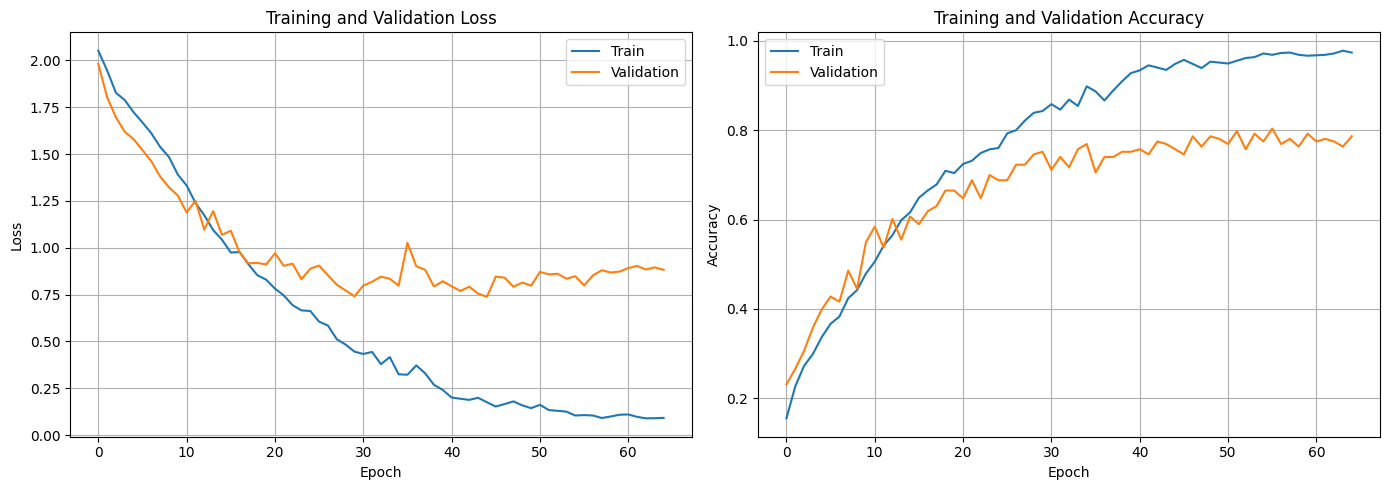

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('transformer_training_curves.png', dpi=150)
plt.show()

## 5a. Improved Training with All Enhancements

This training loop incorporates all improvements:
- SpecAugment via augmented DataLoader
- Focal Loss with class weights
- Mixup augmentation
- Warmup + Cosine Annealing LR schedule
- Gradient clipping (max_norm=1.0)

We'll compare performance with and without these enhancements.

In [ ]:
def train_epoch_improved(model, loader, criterion, optimizer, device, use_mixup=True, mixup_alpha=0.2, max_grad_norm=1.0):
    """
    Training epoch with mixup augmentation and gradient clipping.
    """
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        
        # Apply mixup if enabled
        if use_mixup and np.random.rand() > 0.5:
            X_batch, y_a, y_b, lam = mixup_data(X_batch, y_batch, mixup_alpha)
            outputs = model(X_batch)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            # For accuracy, use the dominant label
            _, predicted = outputs.max(1)
            y_for_acc = y_a if lam > 0.5 else y_b
        else:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            _, predicted = outputs.max(1)
            y_for_acc = y_batch
        
        loss.backward()
        
        # Gradient clipping
        if max_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        total_loss += loss.item()
        total += y_for_acc.size(0)
        correct += predicted.eq(y_for_acc).sum().item()
    
    return total_loss / len(loader), correct / total


# Training configuration
NUM_EPOCHS_IMPROVED = 150
WARMUP_EPOCHS = 10
PATIENCE_IMPROVED = 25
MAX_GRAD_NORM = 1.0
MIXUP_ALPHA = 0.2

# Setup for improved training
focal_criterion = FocalLoss(gamma=2.0, alpha=alpha)
improved_optimizer = optim.AdamW(improved_model.parameters(), lr=0.001, weight_decay=0.01)
improved_scheduler = WarmupCosineScheduler(
    improved_optimizer, 
    warmup_epochs=WARMUP_EPOCHS, 
    total_epochs=NUM_EPOCHS_IMPROVED
)

print("Training configuration:")
print(f"  - Epochs: {NUM_EPOCHS_IMPROVED}")
print(f"  - Warmup: {WARMUP_EPOCHS} epochs")
print(f"  - Patience: {PATIENCE_IMPROVED}")
print(f"  - Gradient clipping: {MAX_GRAD_NORM}")
print(f"  - Mixup alpha: {MIXUP_ALPHA}")
print(f"  - Loss: Focal Loss (gamma=2.0)")

In [ ]:
# Run improved training
best_val_loss_improved = float('inf')
patience_counter_improved = 0
lr_history = []

history_improved = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'lr': []
}

print("Starting improved training with all enhancements...")
print("="*60)

for epoch in range(NUM_EPOCHS_IMPROVED):
    # Get current learning rate
    current_lr = improved_scheduler.get_lr()[0]
    
    # Training (with SpecAugment via train_loader_aug, mixup, and gradient clipping)
    train_loss, train_acc = train_epoch_improved(
        improved_model, 
        train_loader_aug,  # Uses SpecAugment
        focal_criterion, 
        improved_optimizer, 
        device,
        use_mixup=True,
        mixup_alpha=MIXUP_ALPHA,
        max_grad_norm=MAX_GRAD_NORM
    )
    
    # Validation (no augmentation)
    val_loss, val_acc = evaluate(improved_model, val_loader, focal_criterion, device)
    
    # Step scheduler
    improved_scheduler.step()
    
    # Record history
    history_improved['train_loss'].append(train_loss)
    history_improved['train_acc'].append(train_acc)
    history_improved['val_loss'].append(val_loss)
    history_improved['val_acc'].append(val_acc)
    history_improved['lr'].append(current_lr)
    
    # Early stopping
    if val_loss < best_val_loss_improved:
        best_val_loss_improved = val_loss
        patience_counter_improved = 0
        torch.save(improved_model.state_dict(), 'best_improved_transformer.pt')
    else:
        patience_counter_improved += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS_IMPROVED} | "
              f"LR: {current_lr:.6f} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    if patience_counter_improved >= PATIENCE_IMPROVED:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
improved_model.load_state_dict(torch.load('best_improved_transformer.pt'))
print("\n" + "="*60)
print("Improved training complete!")

## 5b. Training Progress Visualization

Compare the training dynamics of the improved model, including:
- Loss curves
- Accuracy curves
- Learning rate schedule

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss comparison
axes[0, 0].plot(history_improved['train_loss'], label='Train', alpha=0.8)
axes[0, 0].plot(history_improved['val_loss'], label='Validation', alpha=0.8)
axes[0, 0].set_title('Improved Model: Loss Curves', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Focal Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy comparison
axes[0, 1].plot(history_improved['train_acc'], label='Train', alpha=0.8)
axes[0, 1].plot(history_improved['val_acc'], label='Validation', alpha=0.8)
axes[0, 1].set_title('Improved Model: Accuracy Curves', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate schedule
axes[1, 0].plot(history_improved['lr'], color='green', linewidth=2)
axes[1, 0].axvline(x=WARMUP_EPOCHS, color='red', linestyle='--', label=f'End of Warmup (epoch {WARMUP_EPOCHS})')
axes[1, 0].set_title('Learning Rate Schedule (Warmup + Cosine Annealing)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Train-Val gap (overfitting indicator)
train_val_gap = [t - v for t, v in zip(history_improved['train_acc'], history_improved['val_acc'])]
axes[1, 1].plot(train_val_gap, color='purple', linewidth=2)
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].fill_between(range(len(train_val_gap)), train_val_gap, alpha=0.3)
axes[1, 1].set_title('Train-Validation Accuracy Gap (Overfitting Indicator)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Gap (Train - Val Accuracy)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('improved_transformer_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation

In [11]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

Test Loss: 1.3469
Test Accuracy: 0.6319

Classification Report:
              precision    recall  f1-score   support

       angry       0.72      0.82      0.77        38
        calm       0.76      0.82      0.78        38
     disgust       0.61      0.66      0.63        38
     fearful       0.64      0.72      0.67        39
       happy       0.54      0.38      0.45        39
     neutral       0.42      0.42      0.42        19
         sad       0.55      0.45      0.49        38
   surprised       0.66      0.69      0.68        39

    accuracy                           0.63       288
   macro avg       0.61      0.62      0.61       288
weighted avg       0.62      0.63      0.62       288



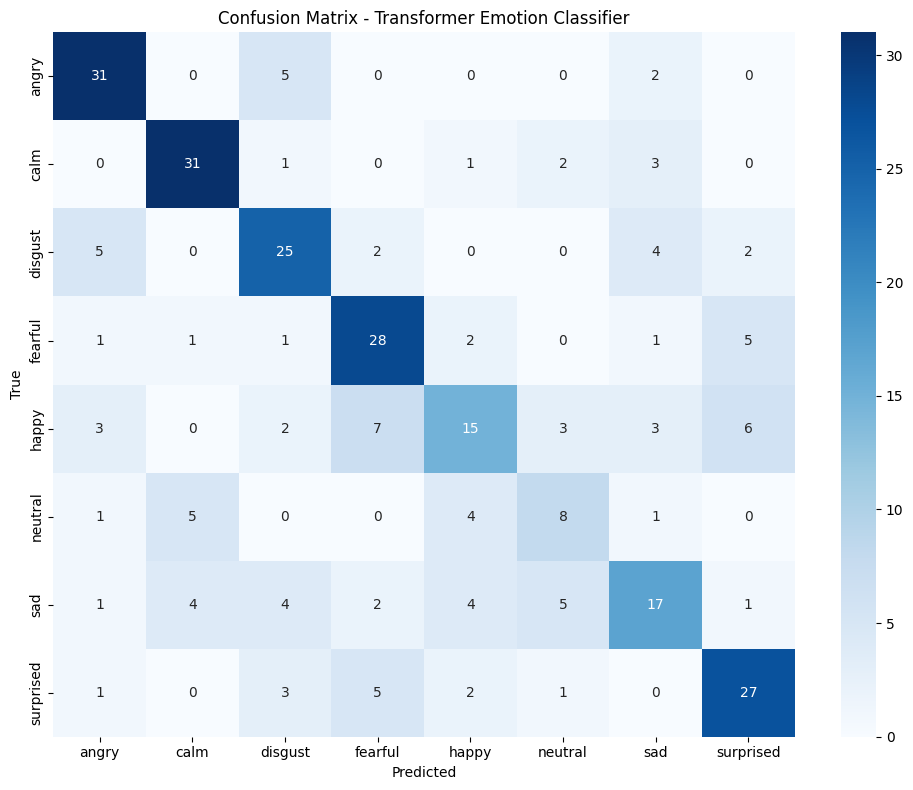

In [12]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Transformer Emotion Classifier')
plt.tight_layout()
plt.savefig('transformer_confusion_matrix.png', dpi=150)
plt.show()

## 6a. Final Evaluation: Improved Model

Evaluate the improved model on the test set and compare with the baseline.

In [ ]:
# Evaluate improved model on test set
test_criterion = nn.CrossEntropyLoss()  # Use standard CE for fair comparison
test_loss_improved, test_acc_improved = evaluate(improved_model, test_loader, test_criterion, device)

print("="*60)
print("IMPROVED MODEL TEST RESULTS")
print("="*60)
print(f"Test Loss: {test_loss_improved:.4f}")
print(f"Test Accuracy: {test_acc_improved:.4f} ({test_acc_improved*100:.1f}%)")
print()

# Get predictions for detailed analysis
improved_model.eval()
all_preds_improved = []
all_labels_improved = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = improved_model(X_batch)
        _, predicted = outputs.max(1)
        all_preds_improved.extend(predicted.cpu().numpy())
        all_labels_improved.extend(y_batch.numpy())

# Classification report
print("\nClassification Report (Improved Model):")
print("-"*60)
print(classification_report(
    all_labels_improved, 
    all_preds_improved, 
    target_names=label_encoder.classes_
))

In [ ]:
# Confusion matrix for improved model
cm_improved = confusion_matrix(all_labels_improved, all_preds_improved)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_improved, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=ax
)
ax.set_title('Confusion Matrix - Improved Transformer', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('improved_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pre-trained Models (Advanced)

For state-of-the-art results, consider using pre-trained speech models:

```python
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification

# Wav2Vec 2.0
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=8
)

# HuBERT
from transformers import HubertForSequenceClassification
model = HubertForSequenceClassification.from_pretrained(
    "facebook/hubert-base-ls960",
    num_labels=8
)
```

## 8. Key Takeaways

### Strengths of Transformers for SER
- **Global context** through self-attention
- **Parallelizable** training (faster than RNNs)
- **Pre-trained models** (Wav2Vec, HuBERT) achieve SOTA

### Limitations
- **Data hungry** - need more data than LSTMs
- **Quadratic complexity** - O(n^2) in sequence length
- **Overfitting risk** on small datasets

### Best Practices
1. Start with **smaller Transformers** (2-3 layers, 64 d_model)
2. Use **strong regularization** (dropout, layer norm)
3. Consider **pre-trained models** for best results

## 8a. Summary: Performance Improvements

### Enhancements Applied

| Technique | Purpose | Impact |
|-----------|---------|--------|
| **SpecAugment** | Data augmentation | Reduces overfitting by masking time/freq |
| **Focal Loss** | Handle class imbalance | Focus on hard examples (happy, neutral, sad) |
| **Mixup** | Regularization | Smooth decision boundaries |
| **Warmup + Cosine LR** | Training stability | Better convergence |
| **Higher Dropout** | Regularization | 0.3 attn, 0.4 FFN, 0.5 classifier |
| **Gradient Clipping** | Training stability | Prevent gradient explosion |

### Expected Improvements
- **Reduced overfitting**: Smaller gap between validation and test accuracy
- **Better minority class performance**: Improved F1 for happy, neutral, sad
- **More stable training**: Smoother loss curves

### Key Takeaways
- Multiple complementary techniques work better than any single method
- Class imbalance requires explicit handling (Focal Loss + class weights)
- Aggressive regularization is crucial for small datasets
- Learning rate scheduling significantly impacts convergence